In [ ]:
# import the libraries
import pandas as pd
import numpy as np
from fbprophet import Prophet
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# WITH PROPHET

In [ ]:
# load data
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = pd.read_csv(path, header=0)
df.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


In [ ]:
# prepare expected column names
# Prophet takes as input a dataframe with columns called 'ds' and 'y' (plus an index)
df.columns = ['ds', 'y']
df['ds']= pd.to_datetime(df['ds'])
df.head()

,ds,y
0,1960-01-01,6550
1,1960-02-01,8728
2,1960-03-01,12026
3,1960-04-01,14395
4,1960-05-01,14587


In [ ]:
# get a train set (by dropping last rows)
train_df = df.drop(df.index[-12:])
train_df.tail()

,ds,y
91,1967-08-01,13434
92,1967-09-01,13598
93,1967-10-01,17187
94,1967-11-01,16119
95,1967-12-01,13713


In [ ]:
# get a test set (by taking last rows of the original df)
test_df = df.iloc[-12:,:]
test_df.head()

,ds,y
96,1968-01-01,13210
97,1968-02-01,14251
98,1968-03-01,20139
99,1968-04-01,21725
100,1968-05-01,26099


In [ ]:
# get y_true values from the test set (used to compute mae)
y_true = test_df['y'].values

In [ ]:
# instantiate the model
model = Prophet()
# fit the model
model.fit(train_df)

INFO:fbprophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# get the 'ds' values to use to predict
X_test = pd.DataFrame(test_df['ds'])
X_test

,ds
96,1968-01-01
97,1968-02-01
98,1968-03-01
99,1968-04-01
100,1968-05-01
101,1968-06-01
102,1968-07-01
103,1968-08-01
104,1968-09-01
105,1968-10-01


In [ ]:
# predict test values
y_pred = model.predict(X_test) # outputs a dataframe, the predicted value is in col yhat
y_hat = y_pred['yhat'].values

In [ ]:
# see how the results are presented
y_pred.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1968-01-01,17591.486094,12825.006102,15973.248308,17591.314236,17591.669453,-3078.492853,-3078.492853,-3078.492853,-3078.492853,-3078.492853,-3078.492853,0.0,0.0,0.0,14512.993241
1,1968-02-01,17639.342540,13356.942622,16419.207258,17637.480643,17641.040167,-2708.433957,-2708.433957,-2708.433957,-2708.433957,-2708.433957,-2708.433957,0.0,0.0,0.0,14930.908583
2,1968-03-01,17684.111474,19366.082307,22316.801828,17679.833300,17688.629035,3158.053867,3158.053867,3158.053867,3158.053867,3158.053867,3158.053867,0.0,0.0,0.0,20842.165341
3,1968-04-01,17731.967920,21555.841560,24618.530053,17724.034998,17739.839211,5268.688682,5268.688682,5268.688682,5268.688682,5268.688682,5268.688682,0.0,0.0,0.0,23000.656602
4,1968-05-01,17778.280610,21790.381470,24891.507814,17766.594420,17789.907478,5571.867867,5571.867867,5571.867867,5571.867867,5571.867867,5571.867867,0.0,0.0,0.0,23350.148477


In [ ]:
# compute the mae
mae = mean_absolute_error(y_true, y_hat)
print('mae:', mae)

mae: 1336.813762330031


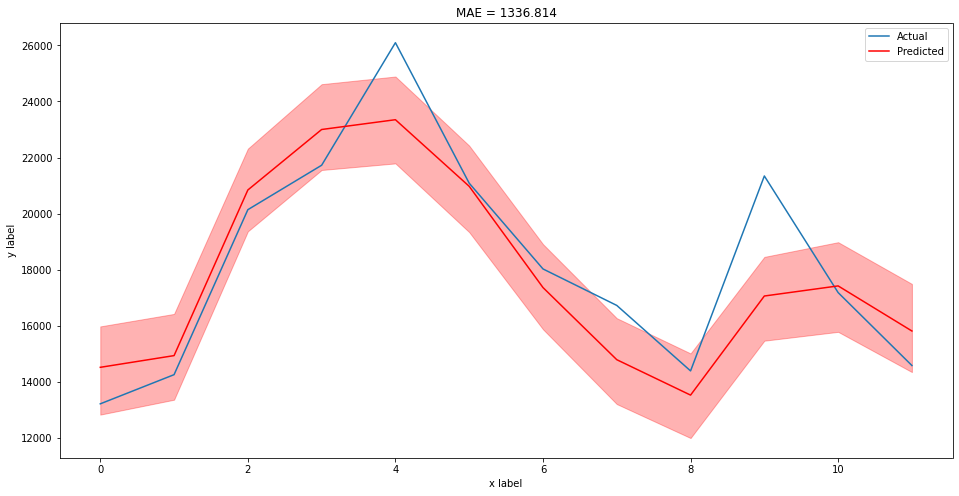

In [ ]:
# plot expected vs actual
plt.figure(figsize=(16,8))
plt.plot(y_true, label='Actual')
plt.plot(y_hat, label='Predicted', color='r')
plt.legend()
plt.xlabel('x label')
plt.ylabel('y label')
plt.title('MAE = {}'.format(round(mae,3)))
plt.fill_between(range(len(y_true)), y_pred['yhat_lower'].values, y_pred['yhat_upper'].values, alpha=0.3, color='r')

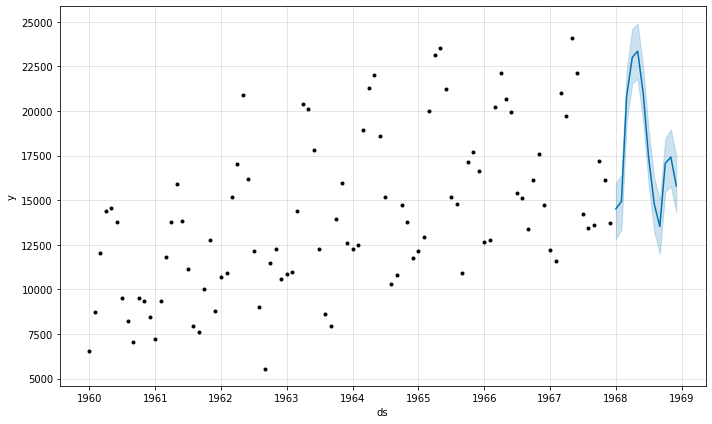

In [ ]:
# plot the model
model.plot(y_pred) # it plots the trainig data and the prediction with the error margin
plt.show()

# SAME TEST BUT WITH MACHINE LEARNING

In [ ]:
# load data
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = pd.read_csv(path, header=0)
df.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


In [ ]:
# check dataframe's info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   108 non-null    object
 1   Sales   108 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


In [ ]:
# get statistical description of the data
df.describe().T.style.background_gradient(subset=["std"], cmap="Reds").background_gradient(subset=["mean"], cmap="Reds")

,count,mean,std,min,25%,50%,75%,max
Sales,108.000000,14595.111111,4525.213913,5568.000000,11391.250000,14076.000000,17595.750000,26099.000000


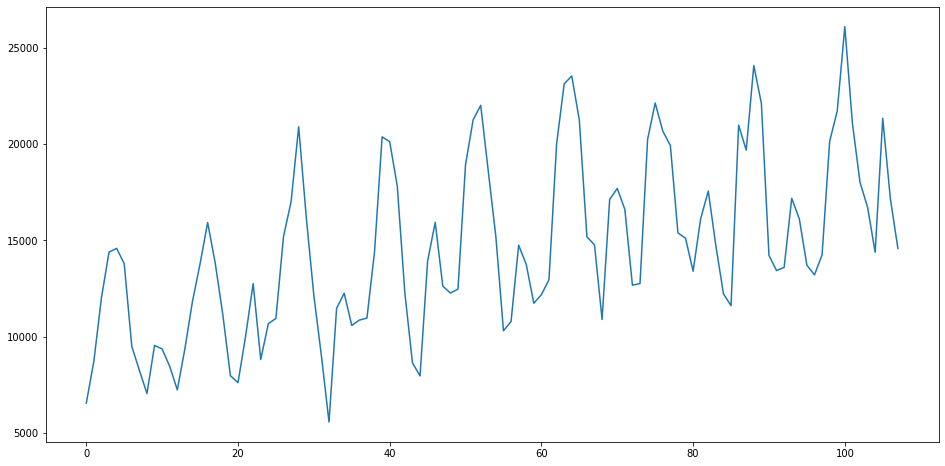

In [ ]:
# plot time series data
plt.figure(figsize=(16,8))
#plt.plot(df['datetime'].iloc[-500:], df['count'].iloc[-500:])
df['Sales'].plot()

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


Text(0.5, 1.0, 'Noise')

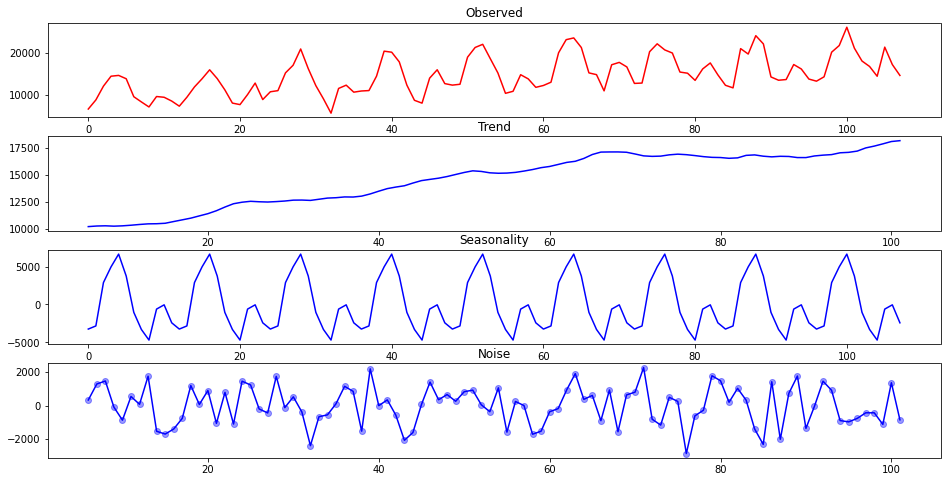

In [ ]:
# seasonal decompose
from statsmodels.tsa.seasonal import seasonal_decompose

dec_results = seasonal_decompose(df['Sales'], freq=12)
obs = dec_results.observed
seas = dec_results.seasonal
trend = dec_results.trend
noise = dec_results.resid

# plot the decomposition (along with observed data)
fig, axs = plt.subplots(4, figsize=(16,8))
    
axs[0].plot(obs, color='r')
axs[0].set_title('Observed')
    
axs[1].plot(trend, color='b')
axs[1].set_title('Trend')
    
axs[2].plot(seas, color='b')
axs[2].set_title('Seasonality')
    
axs[3].plot(noise, color='b')
axs[3].scatter(y=noise, x=range(len(noise)), color='b', alpha=0.4)
axs[3].set_title('Noise') 

<function matplotlib.pyplot.show>

<Figure size 1152x576 with 0 Axes>

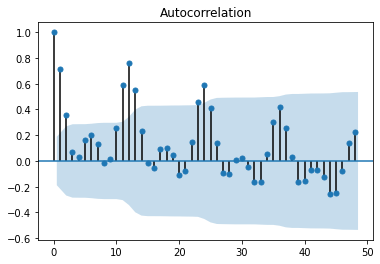

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
# check for autocorrelation
plt.figure(figsize=(16,8))
# plot autocorrelation plot with up to 48 lags (2 days)
plot_acf(df['Sales'],lags=48)
plt.show

In [ ]:
df.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


In [ ]:
df.set_index(pd.to_datetime(df['Month']), inplace=True)

In [ ]:
df.drop('Month', axis=1, inplace=True)

In [ ]:
df['month'] = df.index.month
df['year'] = df.index.year

In [ ]:
X = df[['month', 'year']]
y = df['Sales']

In [ ]:
X_train, X_test = X.iloc[:-12,:], X.iloc[-12:,:]
y_train, y_test = y.iloc[:-12], y.iloc[-12:]

In [ ]:
from sklearn.ensemble import RandomForestRegressor
clf = RandomForestRegressor()
clf.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
y_hat = clf.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_hat)
mae

1823.2466666666667

In [ ]:
# add lag
df_lag = df.copy()
df_lag['one_year_behind'] = df['Sales'].shift(12)
df_lag.dropna(axis=0, how='any', inplace=True)

In [ ]:
X = df_lag.drop('Sales', axis=1)
y = df_lag['Sales']
X_train, X_test = X.iloc[:-12,:], X.iloc[-12:,:]
y_train, y_test = y.iloc[:-12], y.iloc[-12:]

In [ ]:
clf = RandomForestRegressor()
clf.fit(X_train, y_train)
y_hat = clf.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_hat)
mae

1880.6691666666673

In [ ]:
from lightgbm import LGBMRegressor
clf = LGBMRegressor(random_state=42)
clf.fit(X_train, y_train)
y_hat = clf.predict(X_test)
mae = mean_absolute_error(y_test, y_hat)
mae

1644.4700032498076

 # BASELINE WITH NAIVE FORECASTING

In [ ]:
series = df['Sales'].values
series

array([ 6550,  8728, 12026, 14395, 14587, 13791,  9498,  8251,  7049,
        9545,  9364,  8456,  7237,  9374, 11837, 13784, 15926, 13821,
       11143,  7975,  7610, 10015, 12759,  8816, 10677, 10947, 15200,
       17010, 20900, 16205, 12143,  8997,  5568, 11474, 12256, 10583,
       10862, 10965, 14405, 20379, 20128, 17816, 12268,  8642,  7962,
       13932, 15936, 12628, 12267, 12470, 18944, 21259, 22015, 18581,
       15175, 10306, 10792, 14752, 13754, 11738, 12181, 12965, 19990,
       23125, 23541, 21247, 15189, 14767, 10895, 17130, 17697, 16611,
       12674, 12760, 20249, 22135, 20677, 19933, 15388, 15113, 13401,
       16135, 17562, 14720, 12225, 11608, 20985, 19692, 24081, 22114,
       14220, 13434, 13598, 17187, 16119, 13713, 13210, 14251, 20139,
       21725, 26099, 21084, 18024, 16722, 14385, 21342, 17180, 14577])

In [ ]:
time = list(range(len(series)))

In [ ]:
# Define the split time
split_time = -12

# Get the train set 
time_train = time[:split_time]
x_train = series[:split_time]

# Get the validation set
time_valid = time[split_time:]
x_valid = series[split_time:]

In [ ]:
x_valid

array([13210, 14251, 20139, 21725, 26099, 21084, 18024, 16722, 14385,
       21342, 17180, 14577])

In [ ]:
naive_forecast = series[len(series)+split_time-1:-1]
naive_forecast

array([13713, 13210, 14251, 20139, 21725, 26099, 21084, 18024, 16722,
       14385, 21342, 17180])

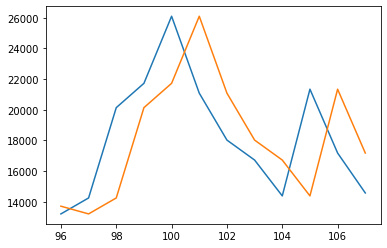

In [ ]:
plt.plot(time_valid, x_valid)
plt.plot(time_valid, naive_forecast)

In [ ]:
mae = mean_absolute_error(x_valid, naive_forecast)
mae

3235.6666666666665

# With time series split cross validation

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
tscv = TimeSeriesSplit(n_splits=3)
model = LGBMRegressor(random_state=42)
parameters = {'n_estimators':range(50,750,100), 'boosting_type':['gbdt', 'dart'] 'max_depth':range(2,16,2)}



grid_search = GridSearchCV(model, parameters, cv=tscv.split(X_train), 
                               scoring='neg_mean_absolute_error', return_train_score=True, 
                               verbose=6, n_jobs=-1)

SyntaxError: ignored

In [ ]:
grid_search.fit(X_train, y_train)

In [ ]:
y_hat = grid_search.predict(X_test)
mae = mean_absolute_error(y_test, y_hat)
mae

In [ ]:
# with XGBRegressor
from xgboost import XGBRegressor
clf = XGBRegressor(random_state=42)
clf.fit(X_train, y_train)
y_hat = clf.predict(X_test)
mae = mean_absolute_error(y_test, y_hat)
mae

# ARIMA
Da quello che ho capito dobbiamo trovare 3 termini (vedi [qui](https://www.machinelearningplus.com/time-series/arima-model-time-series-forecasting-python/)).
C'è il termine d (order of differencing)

In [1]:
import pandas as pd

In [2]:
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = pd.read_csv(path, header=0)
df.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


In [9]:
# trovo il termine d
# prima faccio il ADF test, se p>0.05 devo cercare l'ordine di differencing (altrimenti è 0???)

from statsmodels.tsa.stattools import adfuller
result = adfuller(df.Sales.dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -1.223813
p-value: 0.663269


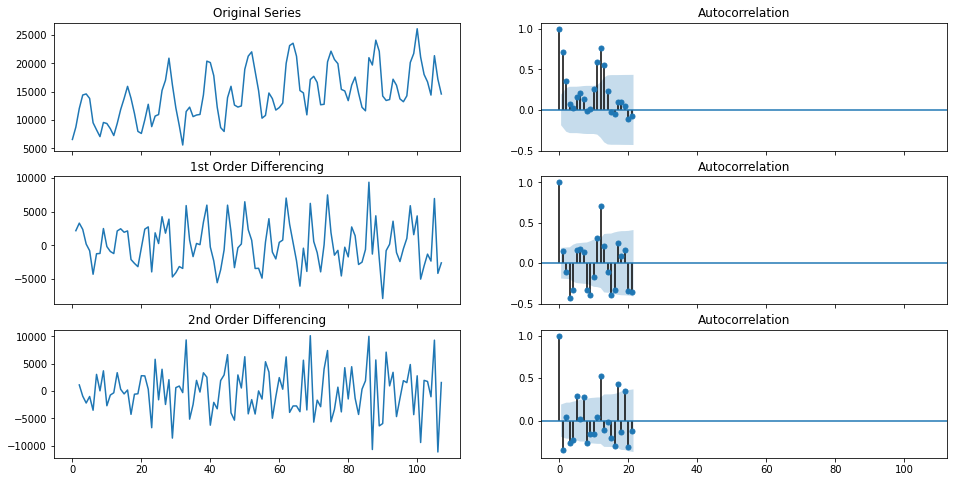

In [13]:
from IPython.core.pylabtools import figsize
# siccome p> 0.05 devo trovare d. Vedo gli autocorrelation plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
# Original Series
fig, axes = plt.subplots(3, 2, sharex=True, figsize=(16,8))
axes[0, 0].plot(df.Sales); axes[0, 0].set_title('Original Series')
plot_acf(df.Sales, ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(df.Sales.diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(df.Sales.diff().dropna(), ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(df.Sales.diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(df.Sales.diff().diff().dropna(), ax=axes[2, 1])

plt.show()

In [14]:
# vedo che dopo 1 differenziazione la serie raggiunge stazionarieta', imposto d=1

/usr/local/lib/python3.7/dist-packages/statsmodels/regression/linear_model.py:1358: RuntimeWarning: invalid value encountered in sqrt
  return rho, np.sqrt(sigmasq)


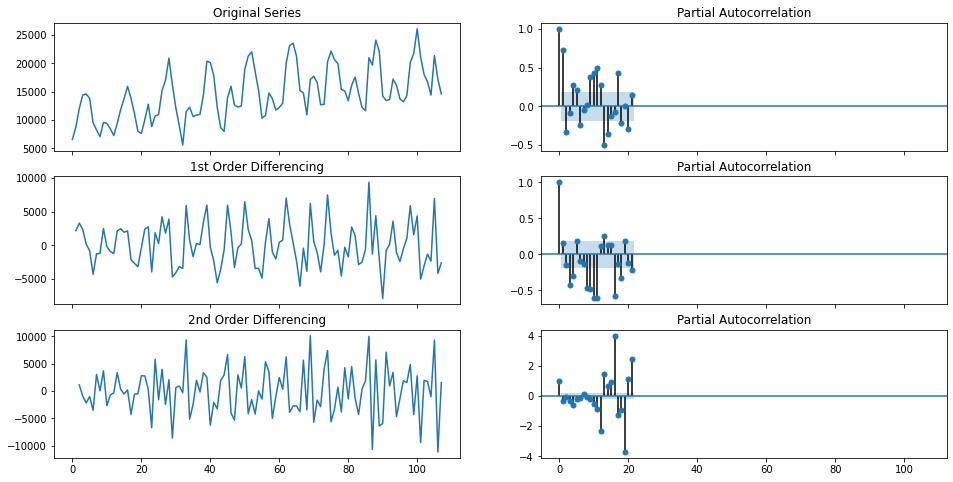

In [15]:
# ora il termine p (di partial autocorrelation)
# faccio la stessa cosa ma invece che plot di autocorrelation uso quello di partial autocorrelation
# Original Series
fig, axes = plt.subplots(3, 2, sharex=True, figsize=(16,8))
axes[0, 0].plot(df.Sales); axes[0, 0].set_title('Original Series')
plot_pacf(df.Sales, ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(df.Sales.diff()); axes[1, 0].set_title('1st Order Differencing')
plot_pacf(df.Sales.diff().dropna(), ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(df.Sales.diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_pacf(df.Sales.diff().diff().dropna(), ax=axes[2, 1])

plt.show()

In [ ]:
# qui devo guardare al grafico di part. autocorrelation del 1st order differencing.
# vedo che nessun lag (a parte il 0) esce dalla zona di significancy, dovrei mettere p=0???
# metto p=1

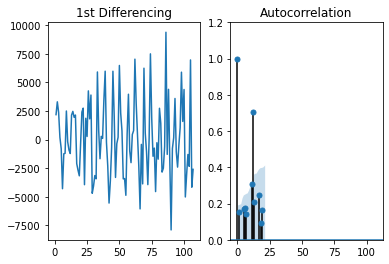

In [16]:
# ora il termine q
# devo fare la stessa cosa di p ma con il plot di autocorrelation, guardare quanti lag
# sono sopra la zona di significancy
fig, axes = plt.subplots(1, 2, sharex=True)
axes[0].plot(df.Sales.diff()); axes[0].set_title('1st Differencing')
axes[1].set(ylim=(0,1.2))
plot_acf(df.Sales.diff().dropna(), ax=axes[1])

plt.show()

In [ ]:
# vedo che solo il lag 0 è sopra, devo mettere q=0???
# intanto provo con q=1

In [22]:
# ora costruisco l'ARIMA model
from statsmodels.tsa.arima_model import ARIMA

# costruisco con i valori (d,p,q) 1,1,1 ARIMA Model
model = ARIMA(df.Sales, order=(1,1,0)) # qui metto (d,p,q)
model_fit = model.fit() # fitto il model, disp=0 non so cosa sia
print(model_fit.summary()) # printo il summary

# allora, con (1,1,1) mi dava errori. con (1,1,2) non convergeva

                              ARMA Model Results                              
Dep. Variable:                  Sales   No. Observations:                  108
Model:                     ARMA(1, 0)   Log Likelihood               -1021.434
Method:                       css-mle   S.D. of innovations           3087.845
Date:                Thu, 05 May 2022   AIC                           2048.868
Time:                        16:48:35   BIC                           2056.914
Sample:                             0   HQIC                          2052.130
                                                                              
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         1.44e+04   1083.657     13.290      0.000    1.23e+04    1.65e+04
ar.L1.Sales     0.7321      0.066     11.105      0.000       0.603       0.861
                                    Roots       

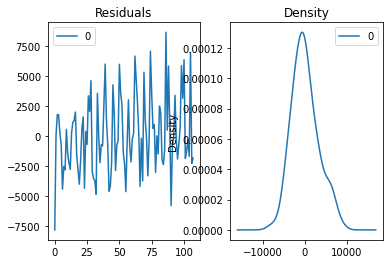

In [23]:
# controllo che i residuals abbiano constant mean and variance, no pattern
# Plot residual errors
residuals = pd.DataFrame(model_fit.resid)
fig, ax = plt.subplots(1,2)
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

# insomma non mi sembra tanto, c'è un trend forse?

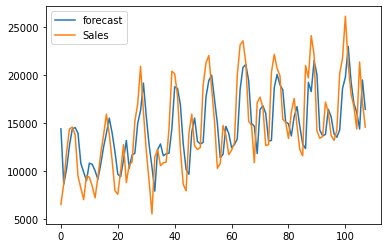

In [24]:
# plot the actual vs. fitted model
model_fit.plot_predict(dynamic=False)
plt.show()

In [27]:
pip install pmdarima

     |████████████████████████████████| 1.4 MB 5.2 MB/s 
     |████████████████████████████████| 9.8 MB 27.3 MB/s 
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2


In [12]:
# provo con autoarima
from statsmodels.tsa.arima_model import ARIMA
from pmdarima.arima import auto_arima



model = auto_arima(df.Sales, start_p=1, start_q=1,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0, 
                      D=0, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=2061.197, Time=0.23 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2389.419, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2062.659, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.19 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.56 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=2060.710, Time=0.36 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.59 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=2046.047, Time=0.79 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=2022.195, Time=1.32 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=2037.575, Time=1.24 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=2030.067, Time=0.89 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=2035.369, Time=1.17 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=2008.720, Time=0.55 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=2033.379, Time=0.18 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=2040.7

In [11]:
model_fit = model.fit()

TypeError: ignored

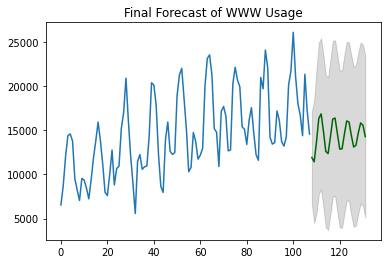

In [13]:
# mi trova un modello (2,0,0) SARIMAX
# ORA VOGLIO FARE PREDICTIONS
import numpy as np
# Forecast
n_periods = 24
fc, confint = model.predict(n_periods=n_periods, return_conf_int=True)
index_of_fc = np.arange(len(df.Sales), len(df.Sales)+n_periods)

# make series for plotting purpose
fc_series = pd.Series(fc, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)

import matplotlib.pyplot as plt
# Plot
plt.plot(df.Sales)
plt.plot(fc_series, color='darkgreen')
plt.fill_between(lower_series.index, 
                 lower_series, 
                 upper_series, 
                 color='k', alpha=.15)

plt.title("Final Forecast of WWW Usage")
plt.show()

In [14]:
fc

array([11908.41914271, 11430.58621755, 13681.62953313, 16362.50507452,
       16854.14808062, 14873.28696088, 12606.54605192, 12363.39396143,
       14264.46362425, 16273.77288758, 16382.82719703, 14617.12695704,
       12872.34075488, 12892.51640474, 14537.9590686 , 16053.95309882,
       15934.92740561, 14412.04160409, 13103.41465672, 13302.258247  ,
       14706.81254278, 15831.05061354, 15570.72765315, 14280.75107038])

In [8]:
# Import data
df2 = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/wwwusage.csv', names=['value'], header=0)
df2

,value
0,88
1,84
2,85
3,85
4,84
...,...
95,222
96,228
97,226
98,222
